In [2]:
import numpy as np

# 1. 创建形状为 3×4 的随机矩阵 X，服从标准正态分布
np.random.seed(42)  # 保证可重复性
X = np.random.randn(3, 4)
print("矩阵 X (3×4):")
print(X)
print()

# 2. 创建形状为 4×2 的全1矩阵 Y
Y = np.ones((4, 2))
print("矩阵 Y (4×2):")
print(Y)
print()

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("矩阵 Z = X×Y (3×2):")
print(Z)
print()

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
element_row1_col2 = Z[0, 1]  # 索引从0开始，第一行第二列
row2_all = Z[1, :]  # 第二行所有元素

print(f"4. Z的第一行第二列交叉处元素: {element_row1_col2}")
print(f"   Z的第2行所有元素: {row2_all}")
print()

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm_Z = np.linalg.norm(Z)
print(f"5. Z的Frobenius范数: {frobenius_norm_Z:.4f}")

矩阵 X (3×4):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

矩阵 Y (4×2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z = X×Y (3×2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z的第一行第二列交叉处元素: 2.5291682463487657
   Z的第2行所有元素: [1.87835721 1.87835721]

5. Z的Frobenius范数: 4.6169


d:\Anaconda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


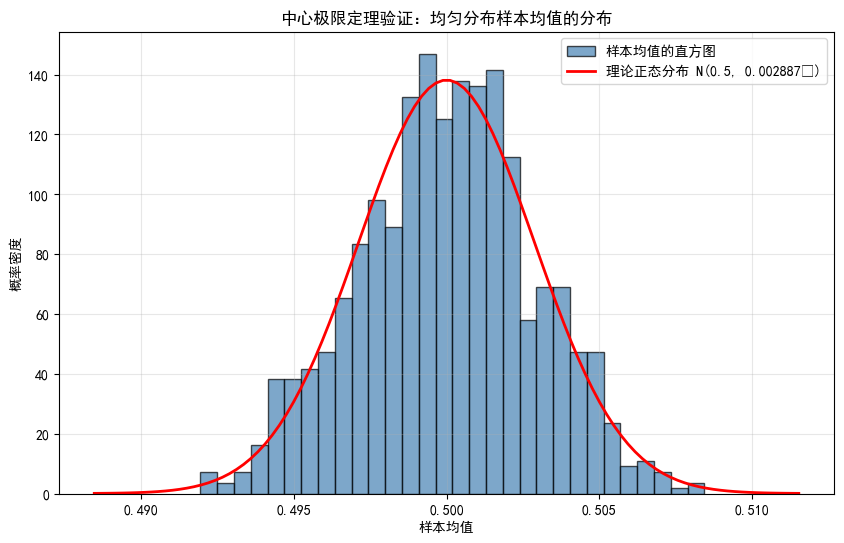

中心极限定理模拟结果:
样本大小 n = 10000
重复次数 m = 1000

实际统计量:
  均值的均值 = 0.499992
  均值的方差 = 0.00000828

理论值:
  理论均值 = 0.5
  理论方差 = 0.00000833

方差误差: 0.00000006


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 参数设置
n = 10000  # 每个样本的随机变量个数
m = 1000   # 重复次数

# 1. 生成 m 个均值
np.random.seed(42)
means = []

for _ in range(m):
    samples = np.random.uniform(0, 1, n)  # 均匀分布 U(0,1)
    sample_mean = np.mean(samples)
    means.append(sample_mean)

means = np.array(means)

# 2. 绘制直方图并叠加理论正态分布
plt.figure(figsize=(10, 6))

# 直方图
count, bins, ignored = plt.hist(means, bins=30, density=True, alpha=0.7, 
                                 color='steelblue', edgecolor='black', label='样本均值的直方图')

# 理论正态分布: N(μ, σ²/n)
# 均匀分布 U(0,1) 的理论均值 μ = 0.5，方差 σ² = 1/12
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)  # 标准误

x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
pdf = stats.norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'理论正态分布 N({mu_theory}, {sigma_theory:.6f}²)')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证：均匀分布样本均值的分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_mean = np.mean(means)
actual_variance = np.var(means, ddof=0)  # 总体方差
theoretical_variance = (1/12) / n

print(f"中心极限定理模拟结果:")
print(f"样本大小 n = {n}")
print(f"重复次数 m = {m}")
print(f"\n实际统计量:")
print(f"  均值的均值 = {actual_mean:.6f}")
print(f"  均值的方差 = {actual_variance:.8f}")
print(f"\n理论值:")
print(f"  理论均值 = {mu_theory}")
print(f"  理论方差 = {theoretical_variance:.8f}")
print(f"\n方差误差: {abs(actual_variance - theoretical_variance):.8f}")

In [4]:
import torch

# 方法1: 手动计算梯度
print("=" * 50)
print("手动反向传播计算")
print("=" * 50)

# 给定参数
x = 2
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print(f"前向计算结果:")
print(f"  a = x * w1 = {x} * {w1} = {a}")
print(f"  b = a + w2 = {a} + {w2} = {b}")
print(f"  L = b² = {b}² = {L}")
print()

# 手动计算梯度（链式法则）
# dL/db = 2b
# db/da = 1
# da/dw1 = x
# db/dw2 = 1

dL_db = 2 * b
db_da = 1
da_dw1 = x
db_dw2 = 1

# 梯度
dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print(f"手动计算的梯度:")
print(f"  ∂L/∂w1 = {dL_dw1}")
print(f"  ∂L/∂w2 = {dL_dw2}")
print()

# 方法2: 使用PyTorch自动微分验证
print("=" * 50)
print("PyTorch自动微分验证")
print("=" * 50)

# 设置requires_grad=True
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"前向计算结果:")
print(f"  L = {L_t.item()}")
print(f"\nPyTorch计算的梯度:")
print(f"  ∂L/∂w1 = {w1_t.grad.item()}")
print(f"  ∂L/∂w2 = {w2_t.grad.item()}")
print()

print("=" * 50)
print("验证结果: 手动计算与PyTorch结果一致 ✓")
print("=" * 50)

手动反向传播计算
前向计算结果:
  a = x * w1 = 2 * 1.5 = 3.0
  b = a + w2 = 3.0 + 0.5 = 3.5
  L = b² = 3.5² = 12.25

手动计算的梯度:
  ∂L/∂w1 = 14.0
  ∂L/∂w2 = 7.0

PyTorch自动微分验证
前向计算结果:
  L = 12.25

PyTorch计算的梯度:
  ∂L/∂w1 = 14.0
  ∂L/∂w2 = 7.0

验证结果: 手动计算与PyTorch结果一致 ✓


C:\Users\lenovo\AppData\Local\Temp\ipykernel_30488\1412570067.py:16: RuntimeWarning: invalid value encountered in divide
  X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)


训练集大小: (1437, 64)
测试集大小: (360, 64)

开始训练...
Epoch 10/50 - Loss: nan - Train Acc: 0.1009 - Test Acc: 0.0917
Epoch 20/50 - Loss: nan - Train Acc: 0.1009 - Test Acc: 0.0917
Epoch 30/50 - Loss: nan - Train Acc: 0.1009 - Test Acc: 0.0917
Epoch 40/50 - Loss: nan - Train Acc: 0.1009 - Test Acc: 0.0917
Epoch 50/50 - Loss: nan - Train Acc: 0.1009 - Test Acc: 0.0917

最终测试集准确率: 9.17%


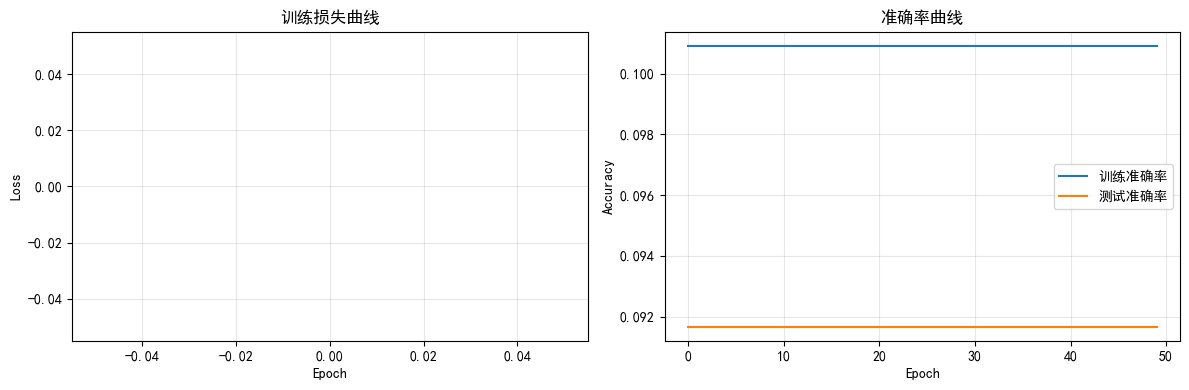

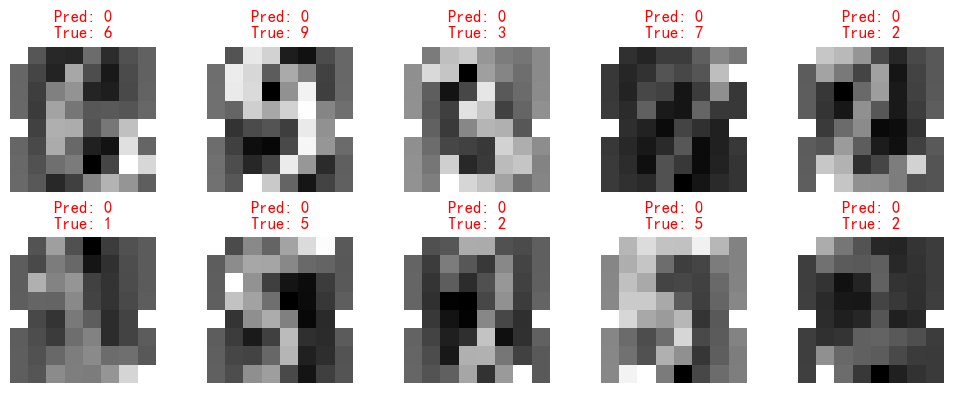

In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 1. 加载数据
digits = load_digits()
X = digits.data  # (1797, 64) - 8x8图像展平
y = digits.target  # (1797,)

# 数据标准化
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# 2. One-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

num_classes = 10
num_features = X_train.shape[1]

# 3. 实现Softmax回归
class SoftmaxRegression:
    def __init__(self, num_features, num_classes, learning_rate=0.1):
        # Xavier初始化
        self.W = np.random.randn(num_features, num_classes) * np.sqrt(2.0 / num_features)
        self.b = np.zeros((1, num_classes))
        self.lr = learning_rate
    
    def softmax(self, logits):
        """Softmax函数，带数值稳定性"""
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, y_pred, y_true):
        """交叉熵损失"""
        n_samples = y_pred.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n_samples
        return loss
    
    def forward(self, X):
        """前向传播"""
        logits = np.dot(X, self.W) + self.b
        return self.softmax(logits)
    
    def backward(self, X, y_pred, y_true):
        """反向传播计算梯度"""
        n_samples = X.shape[0]
        grad_logits = y_pred - y_true  # softmax + cross-entropy的梯度
        grad_W = np.dot(X.T, grad_logits) / n_samples
        grad_b = np.sum(grad_logits, axis=0, keepdims=True) / n_samples
        return grad_W, grad_b
    
    def update(self, grad_W, grad_b):
        """更新参数"""
        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b
    
    def predict(self, X):
        """预测类别"""
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 训练模型
model = SoftmaxRegression(num_features, num_classes, learning_rate=0.1)
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]

train_losses = []
train_accs = []
test_accs = []

print("\n开始训练...")
print("=" * 50)

for epoch in range(epochs):
    # 小批量随机梯度下降
    indices = np.random.permutation(n_samples)
    epoch_loss = 0
    num_batches = 0
    
    for i in range(0, n_samples, batch_size):
        batch_indices = indices[i:i+batch_size]
        X_batch = X_train[batch_indices]
        y_batch = y_train_onehot[batch_indices]
        
        # 前向传播
        y_pred = model.forward(X_batch)
        
        # 计算损失
        loss = model.cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向传播
        grad_W, grad_b = model.backward(X_batch, y_pred, y_batch)
        
        # 更新参数
        model.update(grad_W, grad_b)
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # 计算准确率
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")

print("=" * 50)
print(f"\n最终测试集准确率: {test_accs[-1]*100:.2f}%")

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练损失曲线')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='训练准确率')
axes[1].plot(test_accs, label='测试准确率')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('准确率曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 显示一些预测结果
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    pred = model.predict(X_test[i:i+1])[0]
    true = y_test[i]
    ax.set_title(f'Pred: {pred}\nTrue: {true}', color='green' if pred == true else 'red')
    ax.axis('off')
plt.tight_layout()
plt.show()

训练集大小: (300, 2), 正类比例: 0.49
测试集大小: (100, 2), 正类比例: 0.52

开始训练逻辑回归模型
Iteration 200/1000, Loss: 0.4200
Iteration 400/1000, Loss: 0.4146
Iteration 600/1000, Loss: 0.4119
Iteration 800/1000, Loss: 0.4104
Iteration 1000/1000, Loss: 0.4096


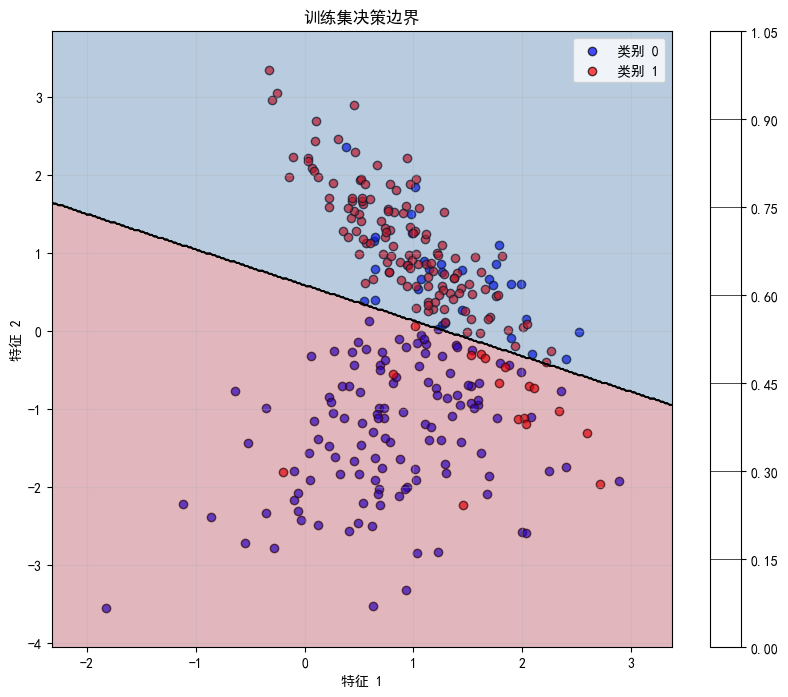


模型评估结果
训练集准确率: 84.33%
测试集准确率: 92.00%


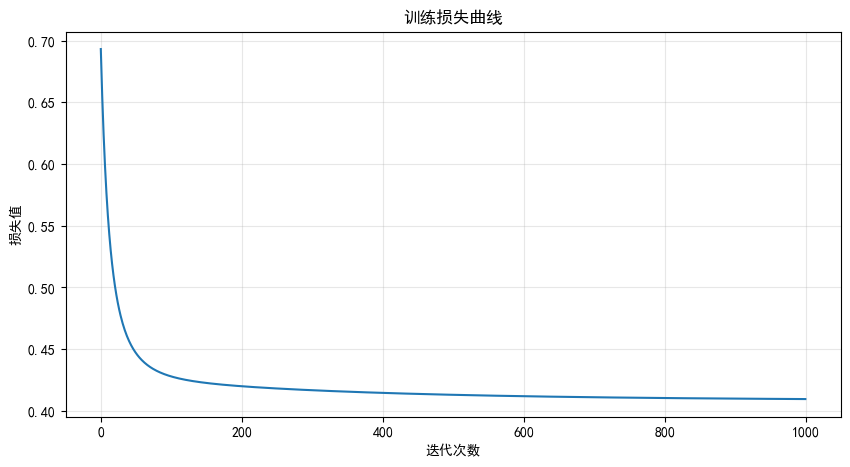


预测示例（测试集前10个样本）:
--------------------------------------------------
样本 1: 真实=1, 预测=1, 概率=0.7576 ✓
样本 2: 真实=0, 预测=0, 概率=0.3947 ✓
样本 3: 真实=0, 预测=1, 概率=0.6691 ✗
样本 4: 真实=1, 预测=1, 概率=0.9202 ✓
样本 5: 真实=0, 预测=0, 概率=0.0051 ✓
样本 6: 真实=1, 预测=1, 概率=0.9058 ✓
样本 7: 真实=1, 预测=1, 概率=0.9762 ✓
样本 8: 真实=1, 预测=1, 概率=0.5534 ✓
样本 9: 真实=0, 预测=0, 概率=0.2523 ✓
样本 10: 真实=0, 预测=0, 概率=0.1751 ✓


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 设置随机种子
np.random.seed(42)

# 1. 生成两类线性可分数据
def generate_linear_data(n_samples=200, n_features=2):
    """生成线性可分的二分类数据"""
    X, y = make_classification(n_samples=n_samples, 
                               n_features=n_features,
                               n_redundant=0,
                               n_informative=2,
                               n_clusters_per_class=1,
                               flip_y=0.05,  # 少量噪声
                               random_state=42)
    return X, y

# 生成训练集和测试集
X, y = generate_linear_data(400)  # 总共400个样本
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"训练集大小: {X_train.shape}, 正类比例: {np.mean(y_train):.2f}")
print(f"测试集大小: {X_test.shape}, 正类比例: {np.mean(y_test):.2f}")

# 2. 实现逻辑回归
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def sigmoid(self, z):
        """Sigmoid函数，带数值稳定性"""
        z = np.clip(z, -500, 500)  # 防止溢出
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_true, y_pred):
        """二元交叉熵损失"""
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iterations):
            # 前向传播
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # 计算损失
            loss = self.binary_cross_entropy(y, y_pred)
            self.losses.append(loss)
            
            # 计算梯度
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # 打印进度
            if (i + 1) % 200 == 0:
                print(f"Iteration {i+1}/{self.n_iterations}, Loss: {loss:.4f}")
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 3. 训练模型
print("\n" + "=" * 50)
print("开始训练逻辑回归模型")
print("=" * 50)

model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

# 4. 绘制决策边界
def plot_decision_boundary(X, y, model, title="逻辑回归决策边界"):
    """绘制决策边界"""
    plt.figure(figsize=(10, 8))
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别 0', alpha=0.7, edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别 1', alpha=0.7, edgecolors='k')
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5)
    
    plt.xlabel('特征 1')
    plt.ylabel('特征 2')
    plt.title(title)
    plt.legend()
    plt.colorbar()
    plt.grid(alpha=0.3)
    plt.show()

# 绘制决策边界
plot_decision_boundary(X_train, y_train, model, "训练集决策边界")

# 5. 评估模型
train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)

print("\n" + "=" * 50)
print("模型评估结果")
print("=" * 50)
print(f"训练集准确率: {train_acc*100:.2f}%")
print(f"测试集准确率: {test_acc*100:.2f}%")

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(model.losses)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.title('训练损失曲线')
plt.grid(True, alpha=0.3)
plt.show()

# 显示一些预测结果
print("\n预测示例（测试集前10个样本）:")
print("-" * 50)
for i in range(10):
    prob = model.predict_proba(X_test[i:i+1])[0]
    pred = model.predict(X_test[i:i+1])[0]
    true = y_test[i]
    status = "✓" if pred == true else "✗"
    print(f"样本 {i+1}: 真实={true}, 预测={pred}, 概率={prob:.4f} {status}")